In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [23]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [24]:
class Module:
    def forward(self, x):
        raise NotImplementedError

    def backward(self, grad_output):
        raise NotImplementedError

    def parameters(self):
        return []

    def zero_grad(self):
        for p, g in self.parameters():
            g.fill(0.0)


class Linear(Module):
    def __init__(self, in_features, out_features):
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features)
        self.b = np.zeros(out_features)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, grad_output):
        self.dW += self.x.T @ grad_output
        self.db += grad_output.sum(axis=0)
        return grad_output @ self.W.T

    def parameters(self):
        return [(self.W, self.dW), (self.b, self.db)]


class ReLU(Module):
    def forward(self, x):
        self.mask = (x > 0)
        return x * self.mask

    def backward(self, grad_output):
        return grad_output * self.mask


class Sigmoid(Module):
    def forward(self, x):
        self.out = 1 / (1 + np.exp(-x))
        return self.out

    def backward(self, grad_output):
        return grad_output * self.out * (1 - self.out)


class Sequential(Module):
    def __init__(self, *layers):
        self.layers = layers

    def forward(self, x):
        for l in self.layers:
            x = l.forward(x)
        return x

    def backward(self, grad_output):
        for l in reversed(self.layers):
            grad_output = l.backward(grad_output)
        return grad_output

    def parameters(self):
        params = []
        for l in self.layers:
            params += l.parameters()
        return params

    def zero_grad(self):
        for l in self.layers:
            l.zero_grad()

class CrossEntropyLoss(Module):
    def forward(self, logits, y):
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp = np.exp(shifted)
        self.probs = exp / exp.sum(axis=1, keepdims=True)
        self.y = y
        N = logits.shape[0]
        loss = -np.log(self.probs[np.arange(N), y] + 1e-9).mean()
        return loss

    def backward(self):
        N = self.y.shape[0]
        grad = self.probs.copy()
        grad[np.arange(N), self.y] -= 1
        grad /= N
        return grad

class SGD:
    def __init__(self, params, lr=1e-2):
        self.params = params
        self.lr = lr

    def step(self):
        for p, g in self.params:
            p -= self.lr * g

    def zero_grad(self):
        for _, g in self.params:
            g.fill(0.0)


In [25]:
def test_forward_backward():
    N, in_features, H, out_features = 100, 10, 30, 3

    torch_model = nn.Sequential(
        nn.Linear(in_features, H),
        nn.ReLU(),
        nn.Linear(H, out_features)
    )
    X_torch = torch.randn(N, in_features, requires_grad=True)
    y_torch = torch.randint(0, out_features, (N,))
    criterion_torch = nn.CrossEntropyLoss()

    output_torch = torch_model(X_torch)
    loss_torch = criterion_torch(output_torch, y_torch)
    loss_torch.backward()


    model = Sequential(
        Linear(in_features, H),
        ReLU(),
        Linear(H, out_features)
    )

    with torch.no_grad():
        model.layers[0].W[:] = torch_model[0].weight.detach().T.numpy()
        model.layers[0].b[:] = torch_model[0].bias.detach().numpy()
        model.layers[2].W[:] = torch_model[2].weight.detach().T.numpy()
        model.layers[2].b[:] = torch_model[2].bias.detach().numpy()

    X = X_torch.detach().numpy()
    y = y_torch.detach().numpy()
    criterion = CrossEntropyLoss()

    output = model.forward(X)
    loss = criterion.forward(output, y)
    grad = criterion.backward()
    model.backward(grad)

    print("Torch loss:", loss_torch.item())
    print("Numpy loss:", loss)

    assert np.allclose(loss, loss_torch.item(), atol=1e-6)
    assert np.allclose(model.layers[0].dW, torch_model[0].weight.grad.T.detach().numpy(), atol=1e-6)
    assert np.allclose(model.layers[0].db, torch_model[0].bias.grad.detach().numpy(), atol=1e-6)
    assert np.allclose(model.layers[2].dW, torch_model[2].weight.grad.T.detach().numpy(), atol=1e-6)
    assert np.allclose(model.layers[2].db, torch_model[2].bias.grad.detach().numpy(), atol=1e-6)


test_forward_backward()

Torch loss: 1.090592384338379
Numpy loss: 1.0905923172670073


In [26]:
df_red = pd.read_csv('/content/winequality-red.csv', sep=';')
df_white = pd.read_csv('/content/winequality-white.csv', sep=';')

In [27]:
df = pd.concat((df_red, df_white), ignore_index=True)
X = df.drop(['quality'], axis=1)
y = df['quality']-3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=SEED)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.long)
y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.long)

In [29]:
class NumpyMLP:
    def __init__(self, input_layer, hidden_layers, output_layer, lr=0.0005, batch_size=32):
        layers = []
        prev_dim = input_layer
        for h in hidden_layers:
            layers.append(Linear(prev_dim, h))
            layers.append(ReLU())
            prev_dim = h
        layers.append(Linear(prev_dim, output_layer))
        self.model = Sequential(*layers)
        self.loss_fn = CrossEntropyLoss()
        self.optimizer = SGD(self.model.parameters(), lr=lr)
        self.batch_size = batch_size

    def predict(self, X):
        logits = self.model.forward(X)
        return np.argmax(logits, axis=1)

In [30]:
class MLP(nn.Module):
    def __init__(self, input_layer, hidden_layers, output_layer, activation='relu'):
        super().__init__()
        layers = []
        prev = input_layer
        act = {'relu': nn.ReLU(),
            'tanh': nn.Tanh()}[activation]
        for h in hidden_layers:
            l = nn.Linear(prev,h)
            nn.init.kaiming_normal_(l.weight, nonlinearity='relu')
            nn.init.zeros_(l.bias)
            layers.append(l)
            layers.append(act)
            prev = h
        layers.append(nn.Linear(prev, output_layer))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [31]:
lr=0.0005
batch_size = 32
hidden_layers = (512, 256, 128, 64)
epoches = 20
num_classes = y_train_t.unique().shape[0]

In [32]:
model = NumpyMLP(X_train_t.shape[1], hidden_layers, num_classes)
torch_model = MLP(X_train_t.shape[1], hidden_layers, num_classes)

In [33]:
torch_criterion = nn.CrossEntropyLoss()
torch_optimizer = optim.SGD(torch_model.parameters(), lr=lr)
torch_ds = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(torch_ds, batch_size=batch_size, shuffle=True)

In [34]:
criterion = CrossEntropyLoss()
optimizer = SGD(model.model.parameters(), lr=lr)

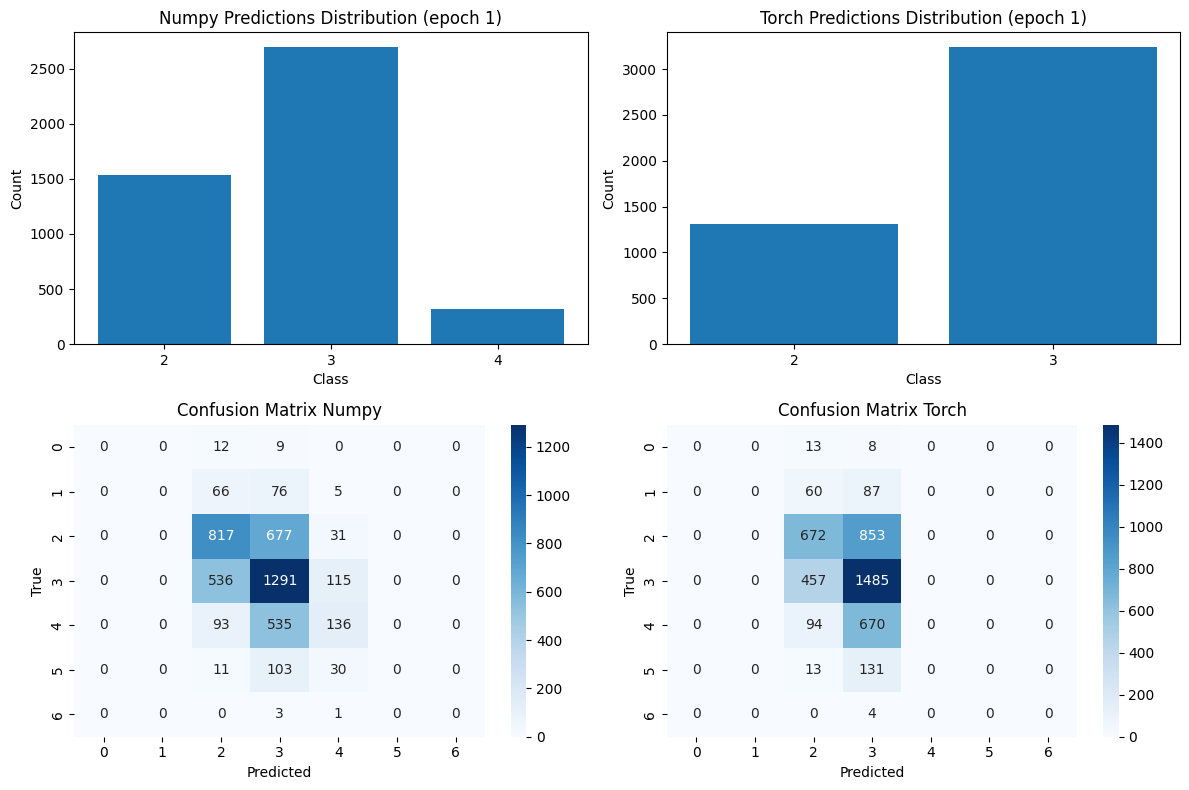

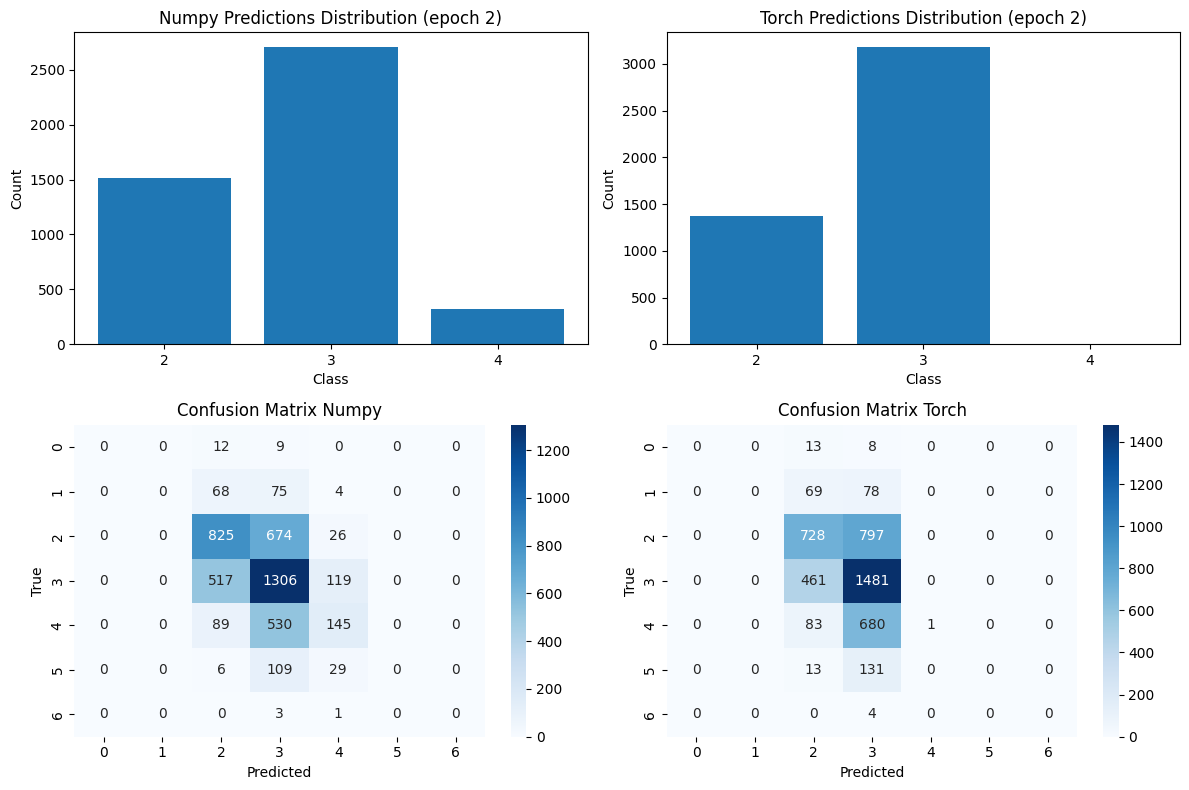

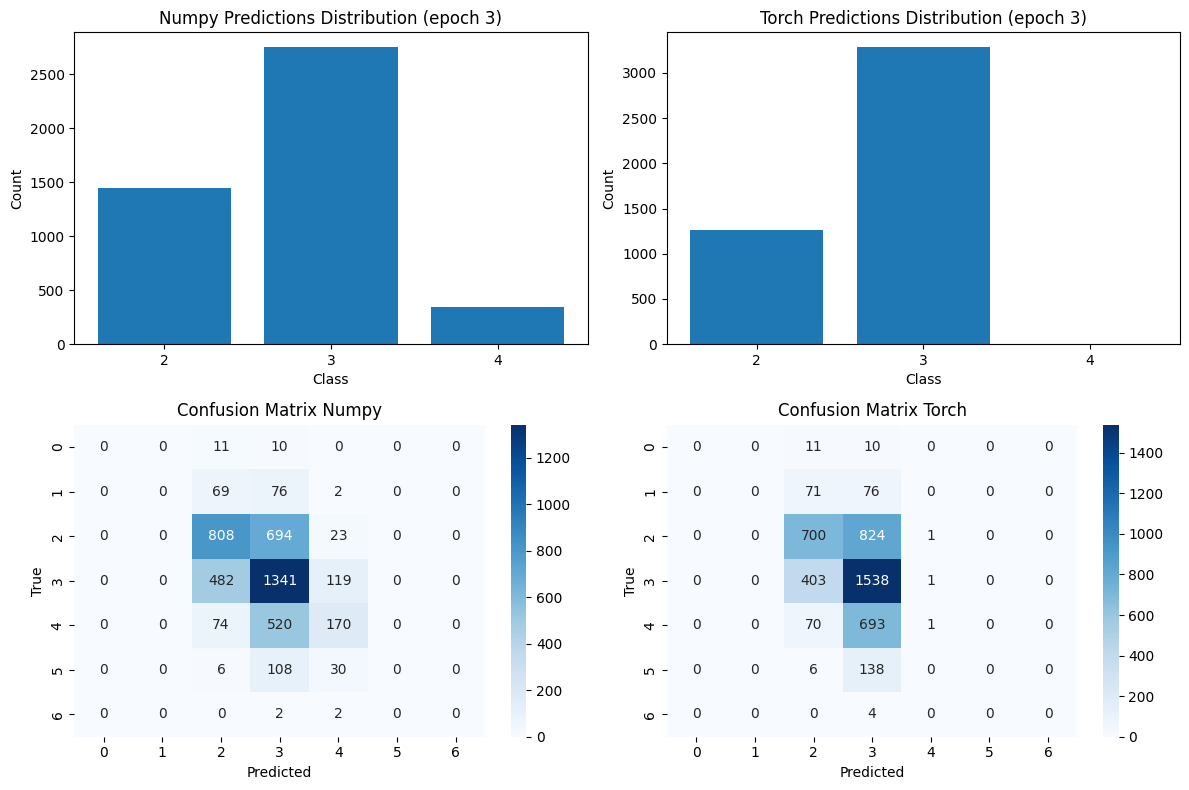

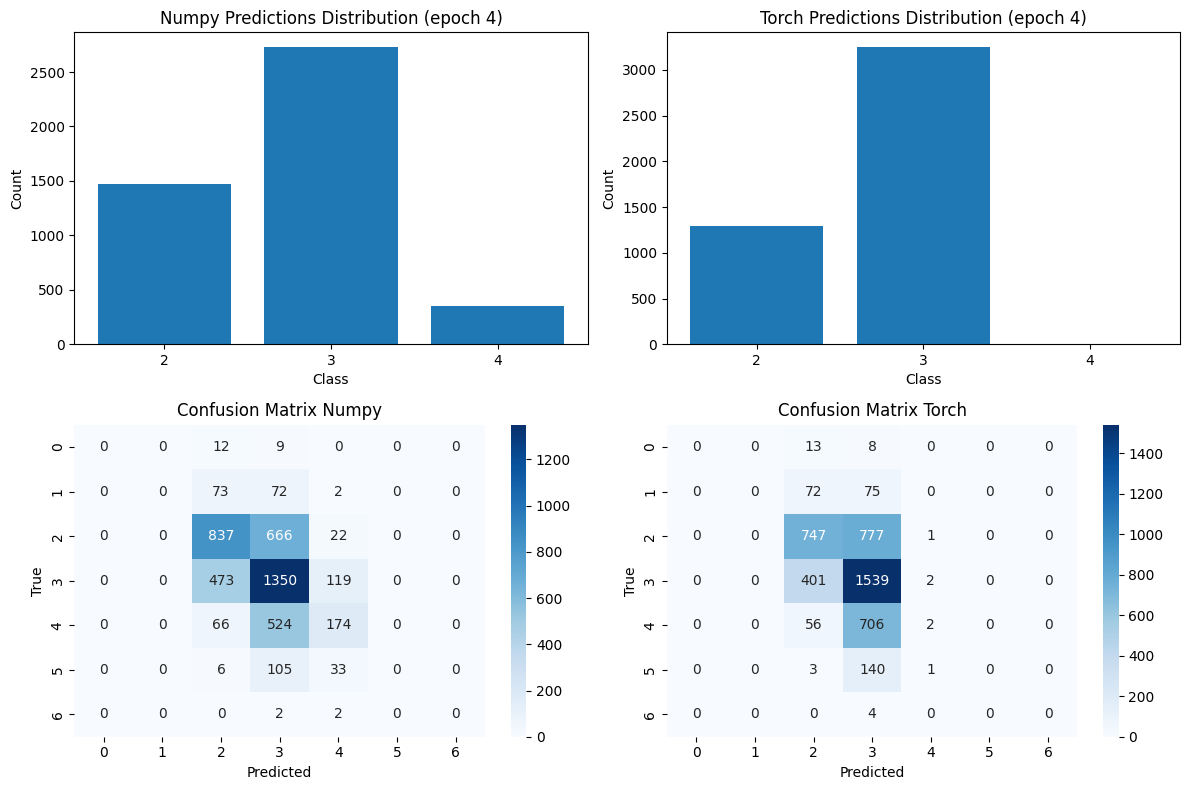

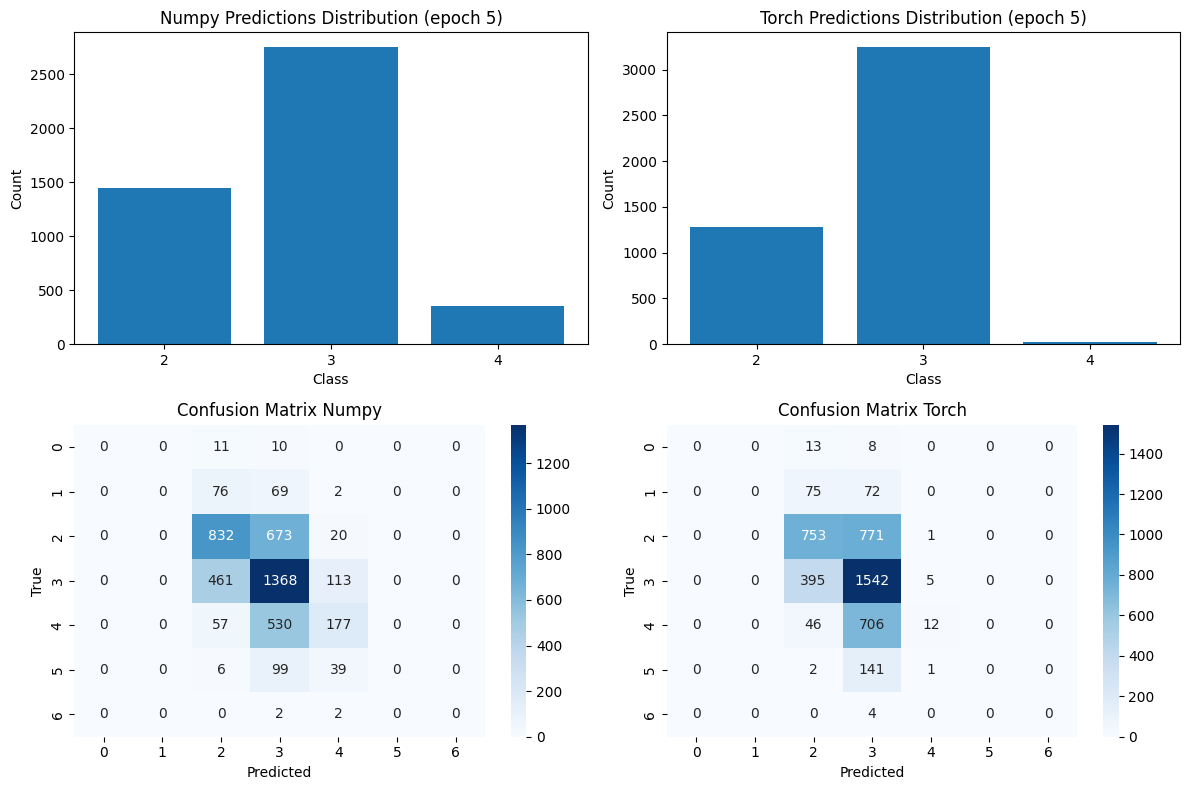

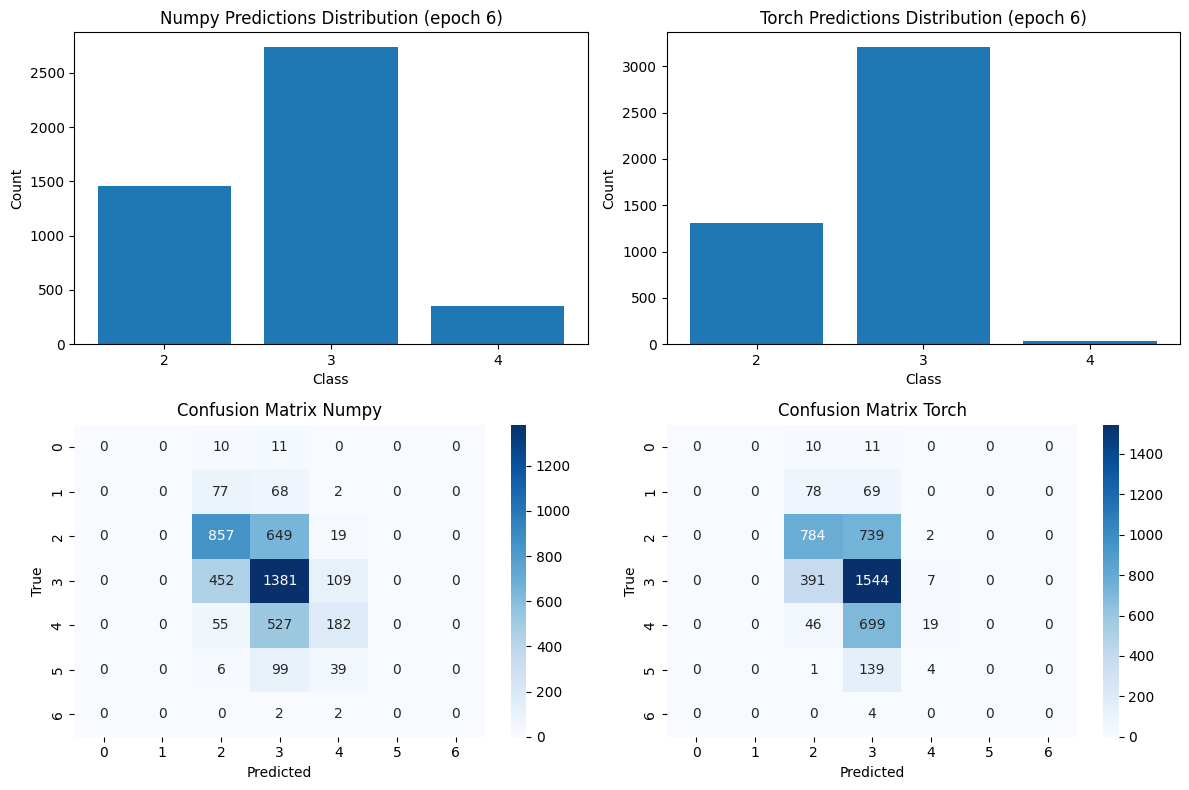

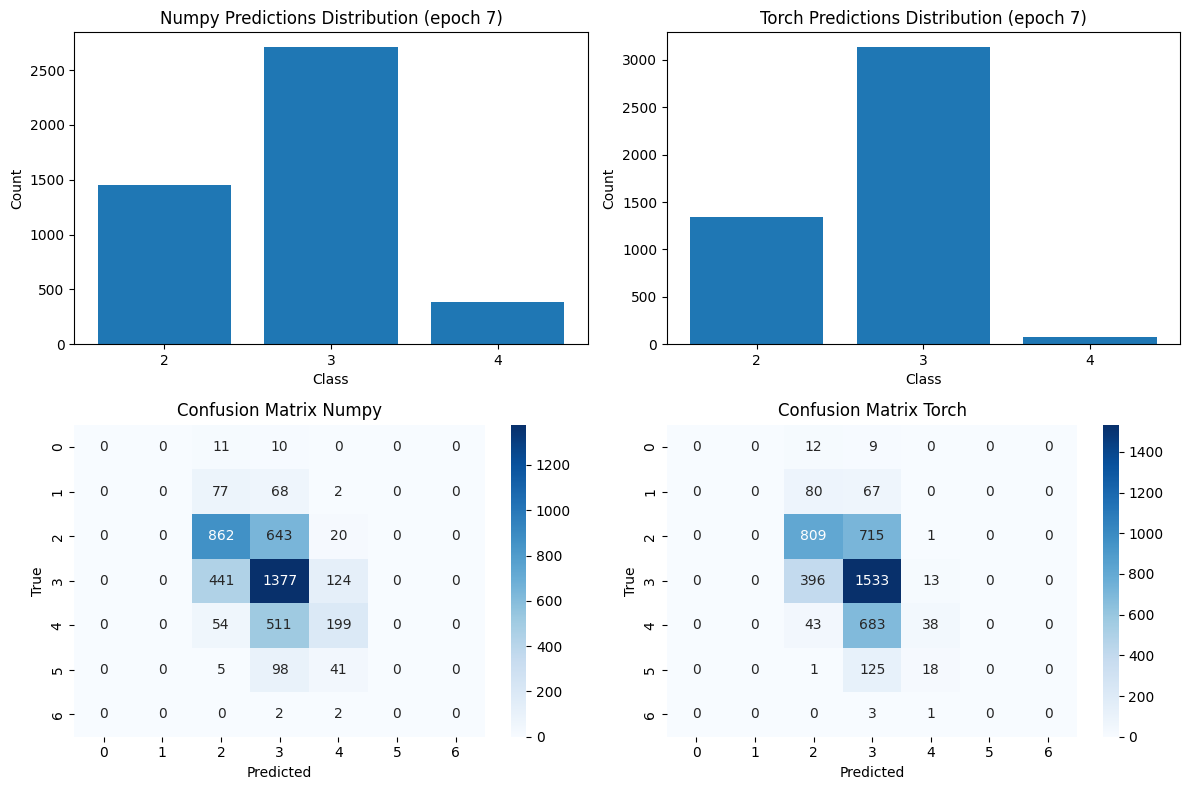

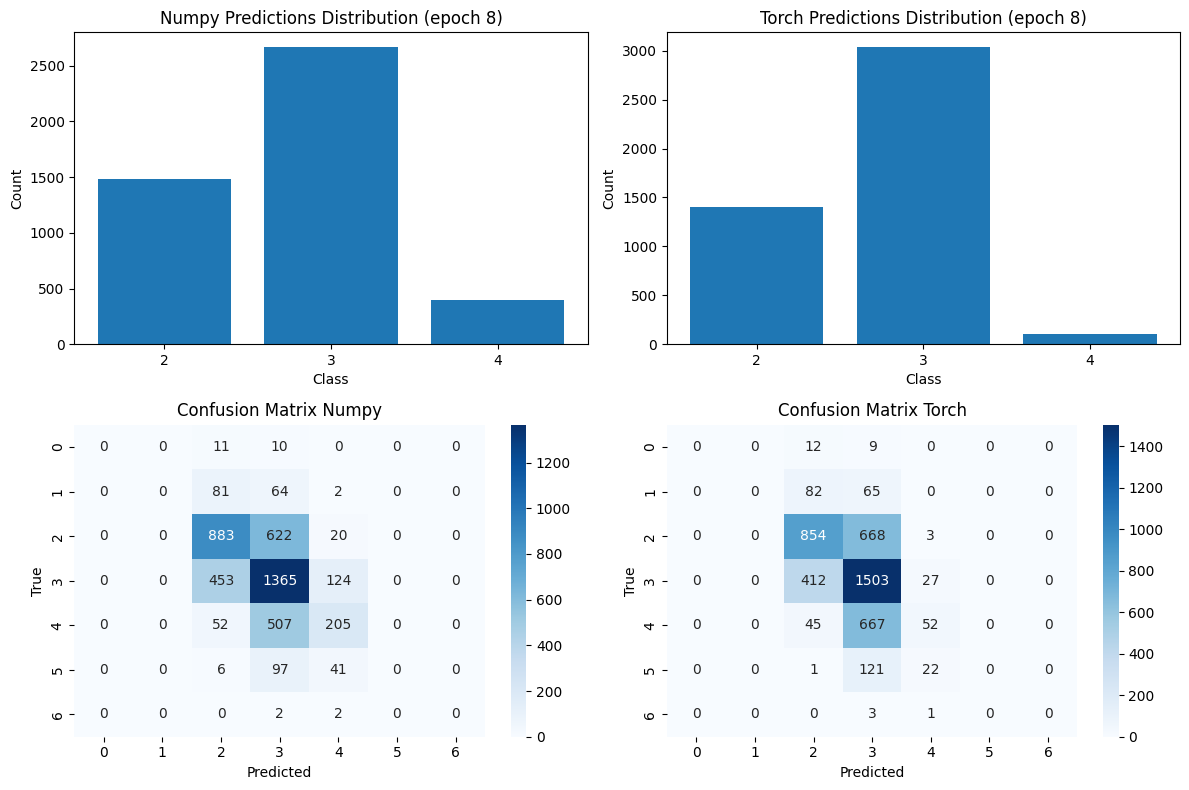

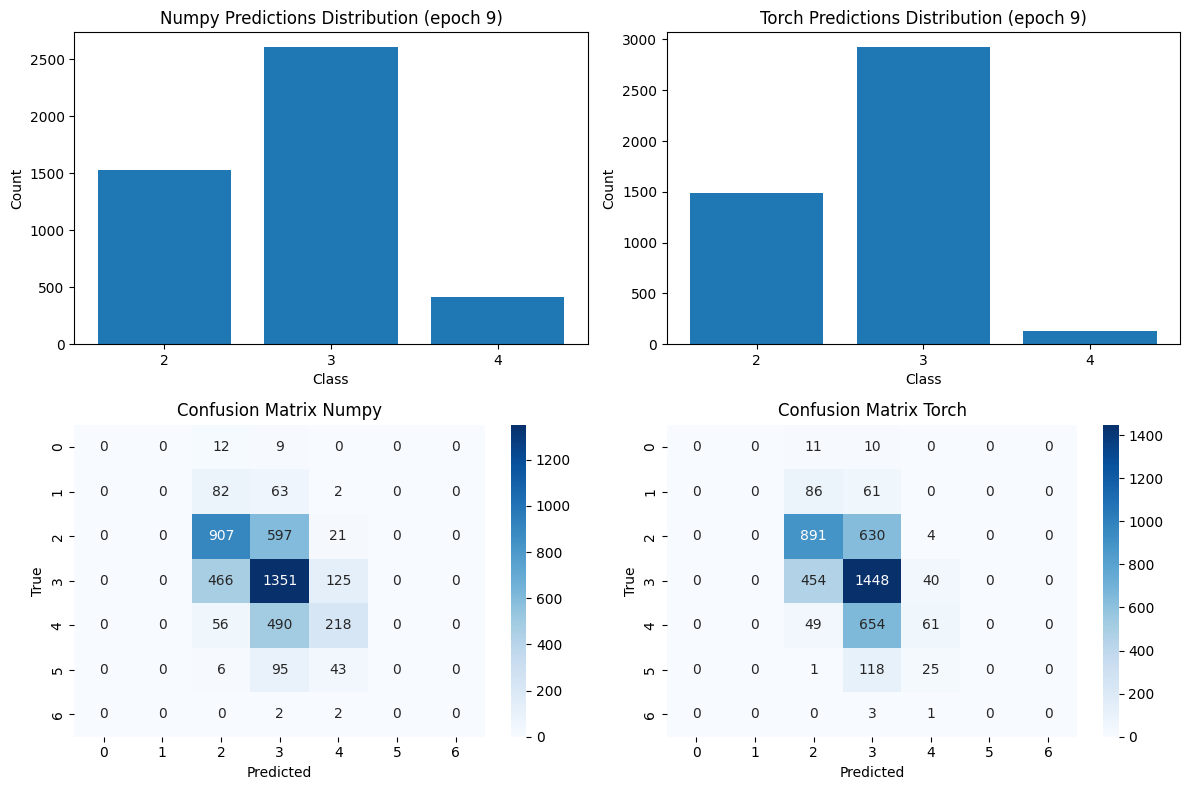

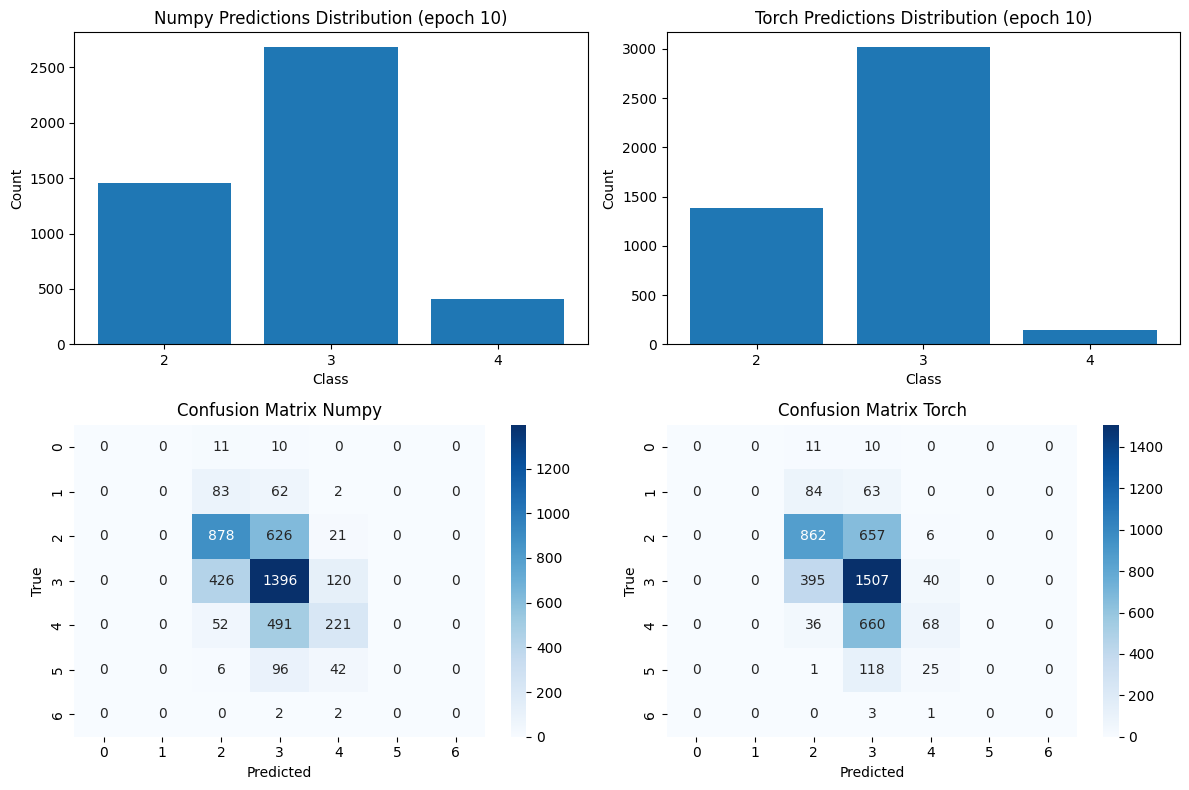

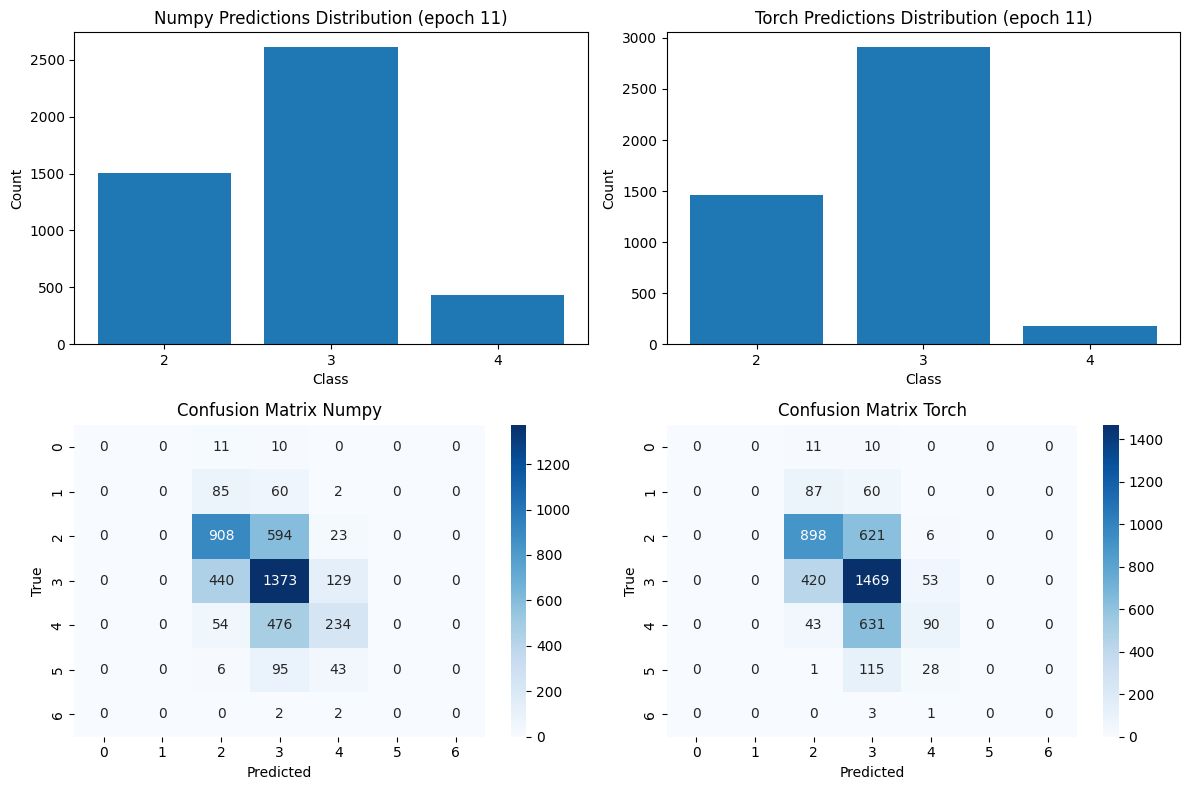

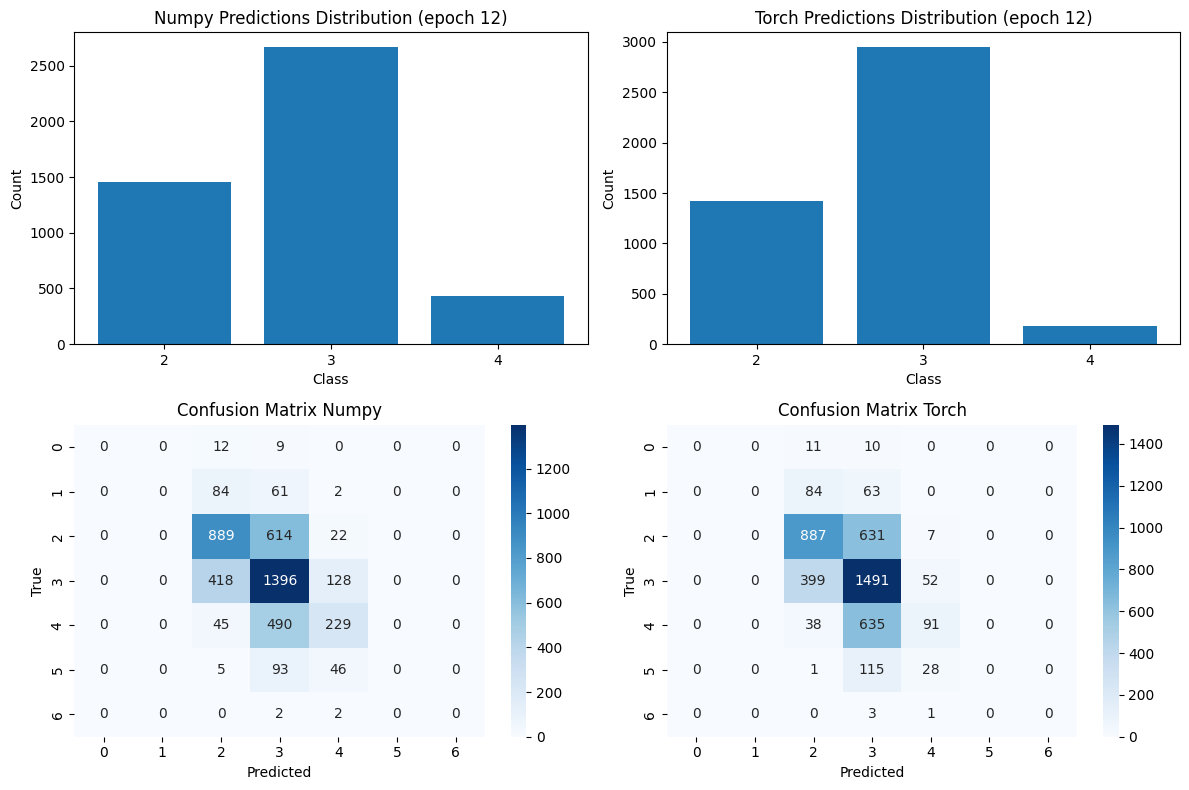

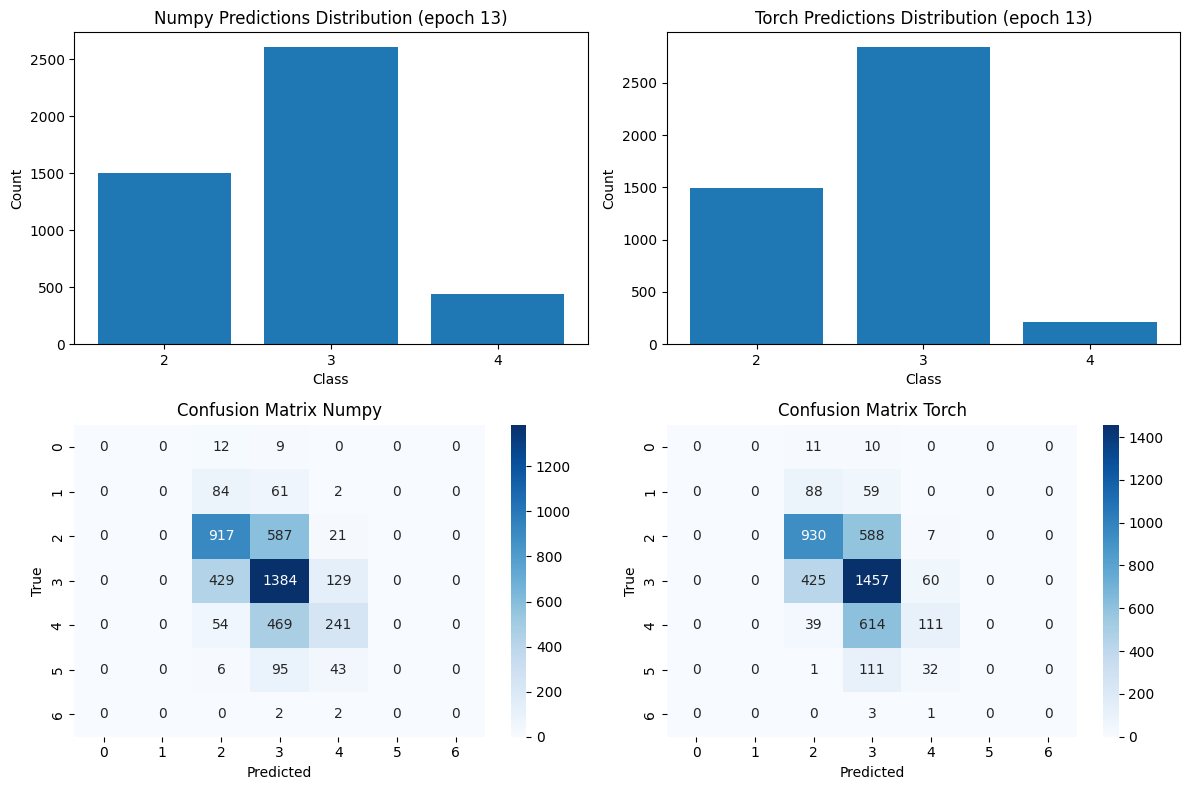

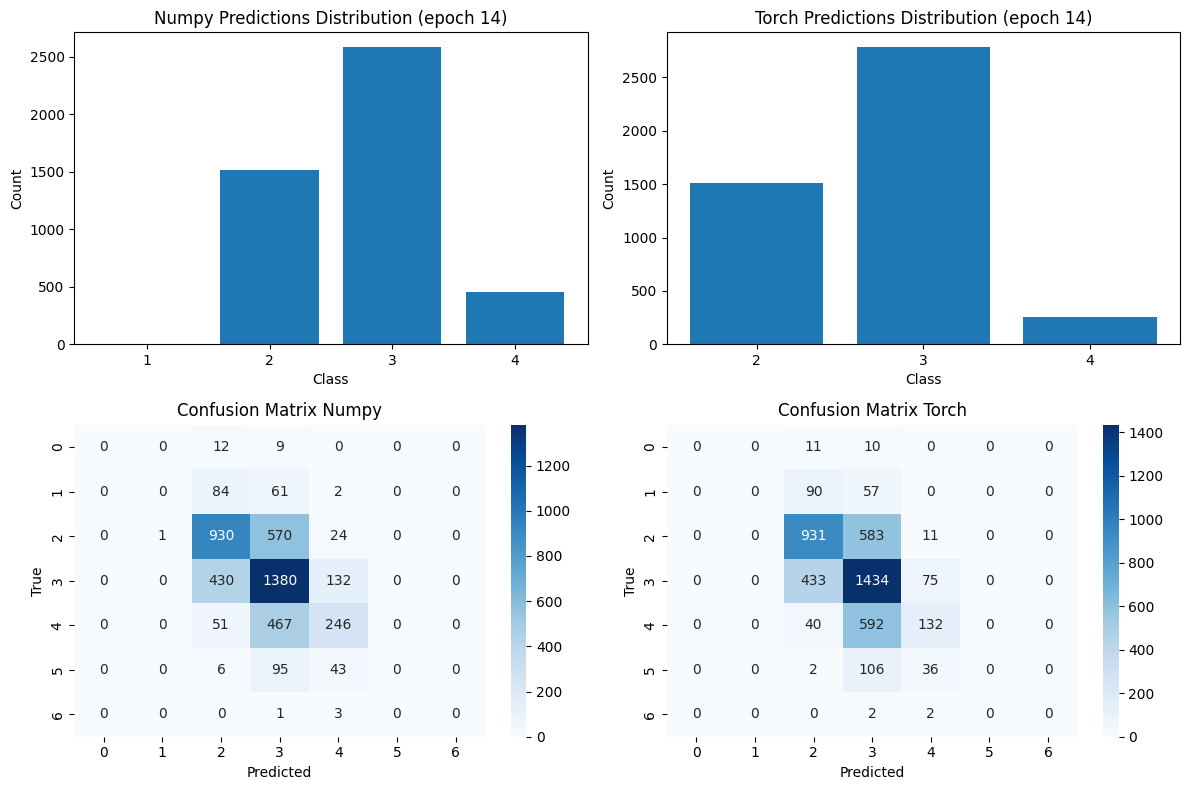

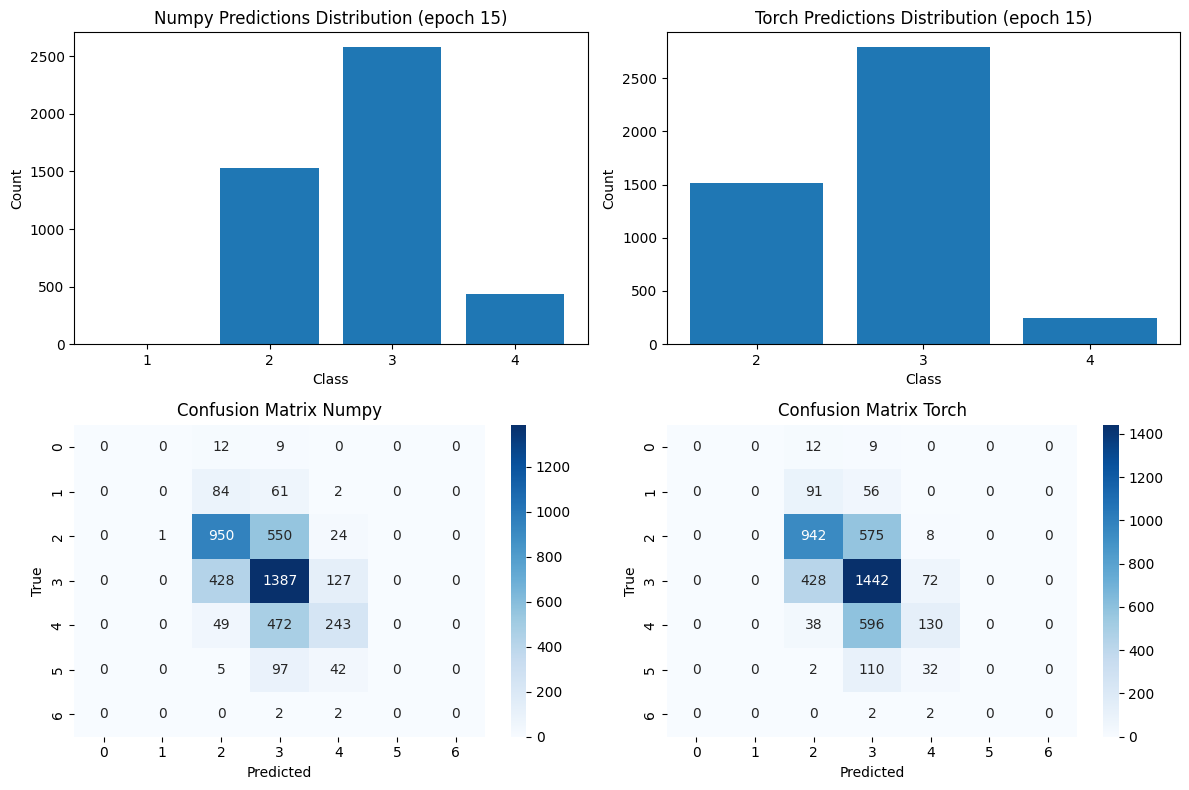

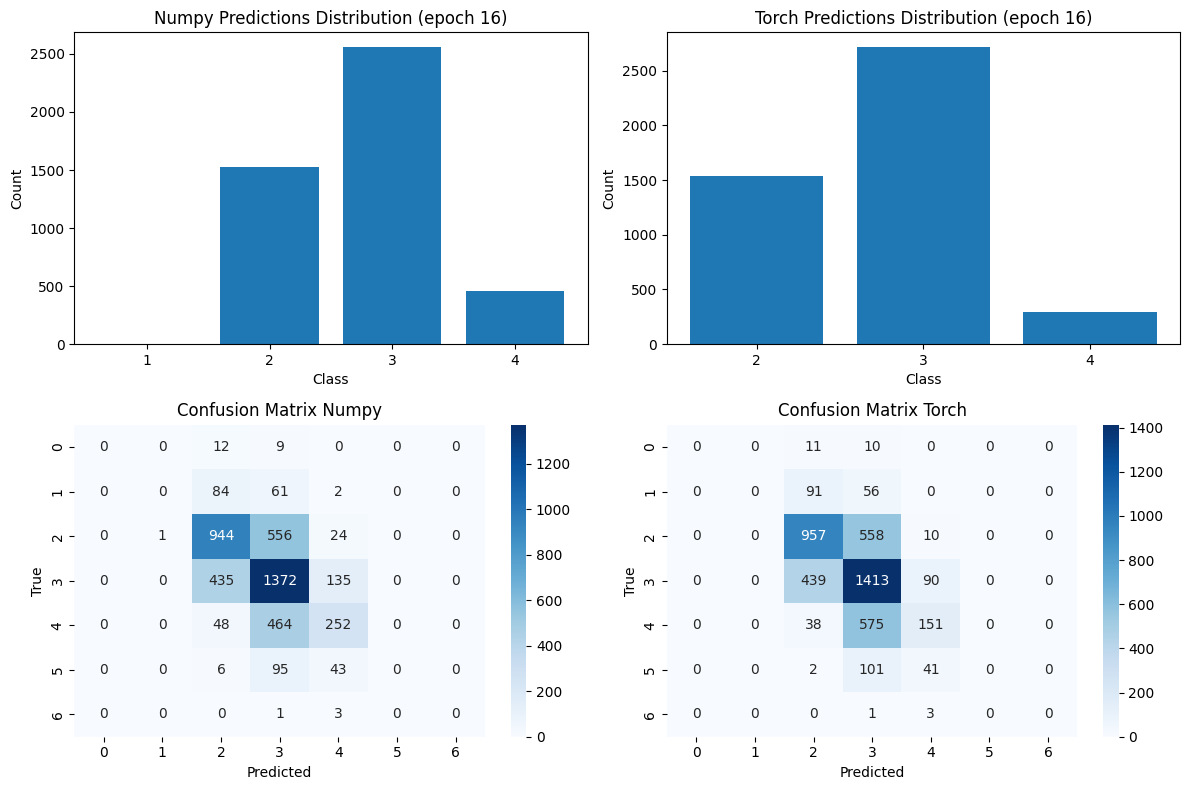

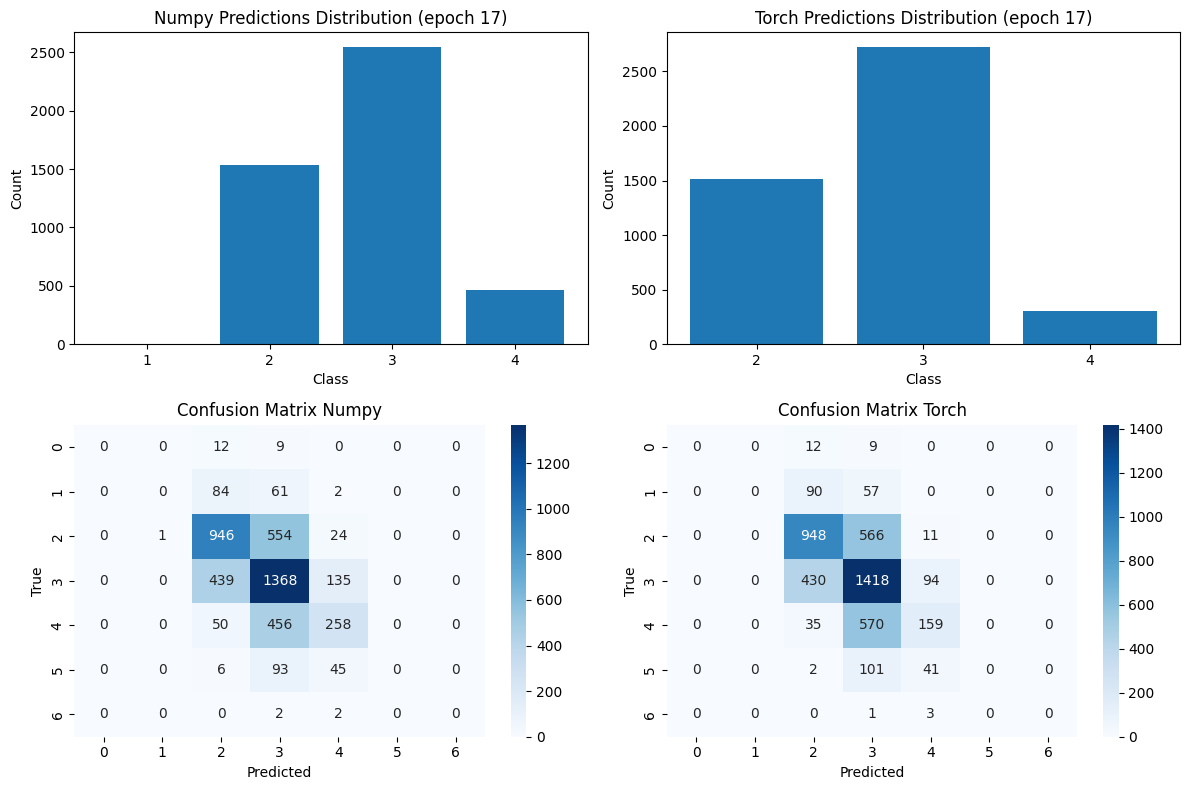

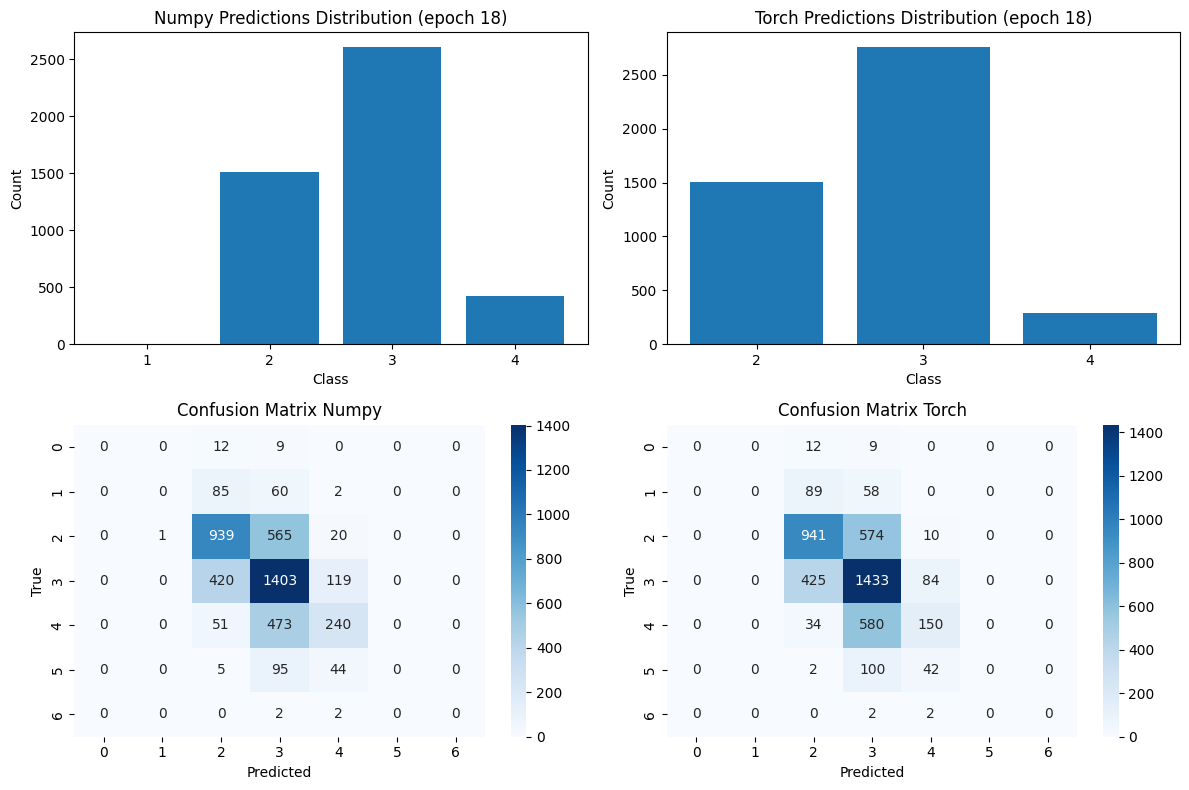

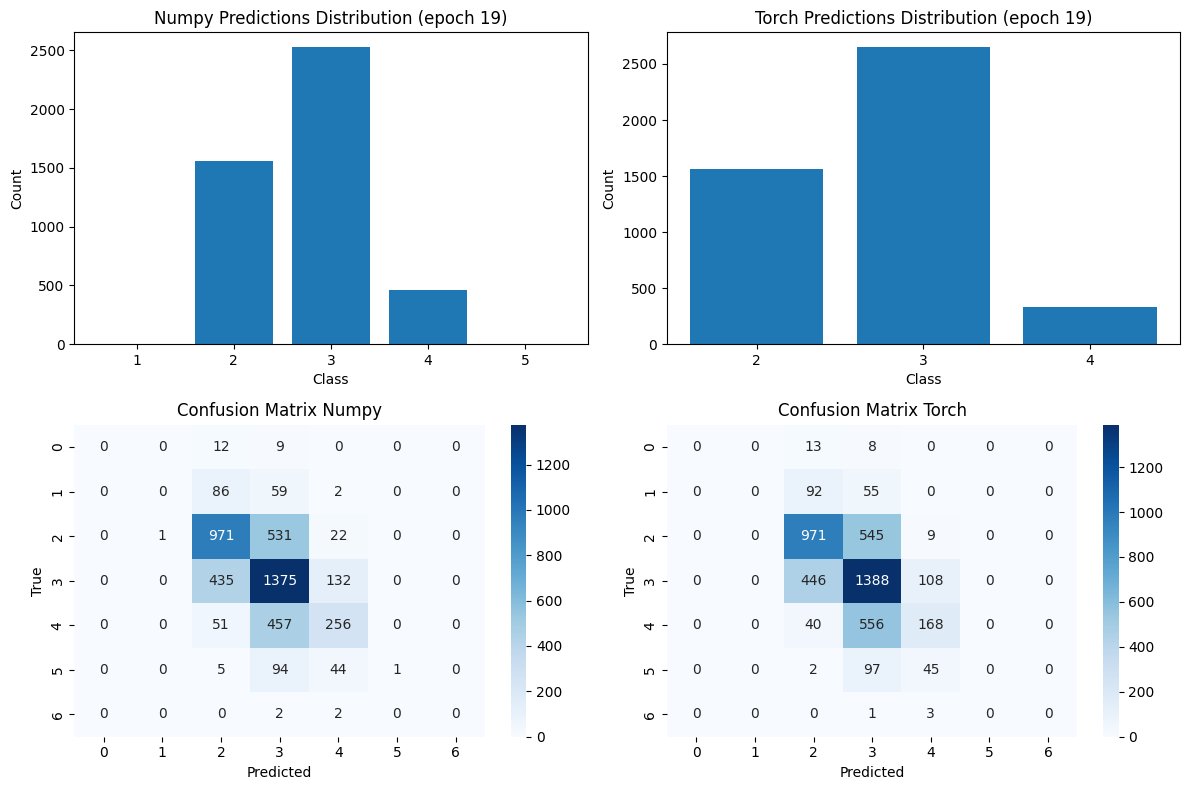

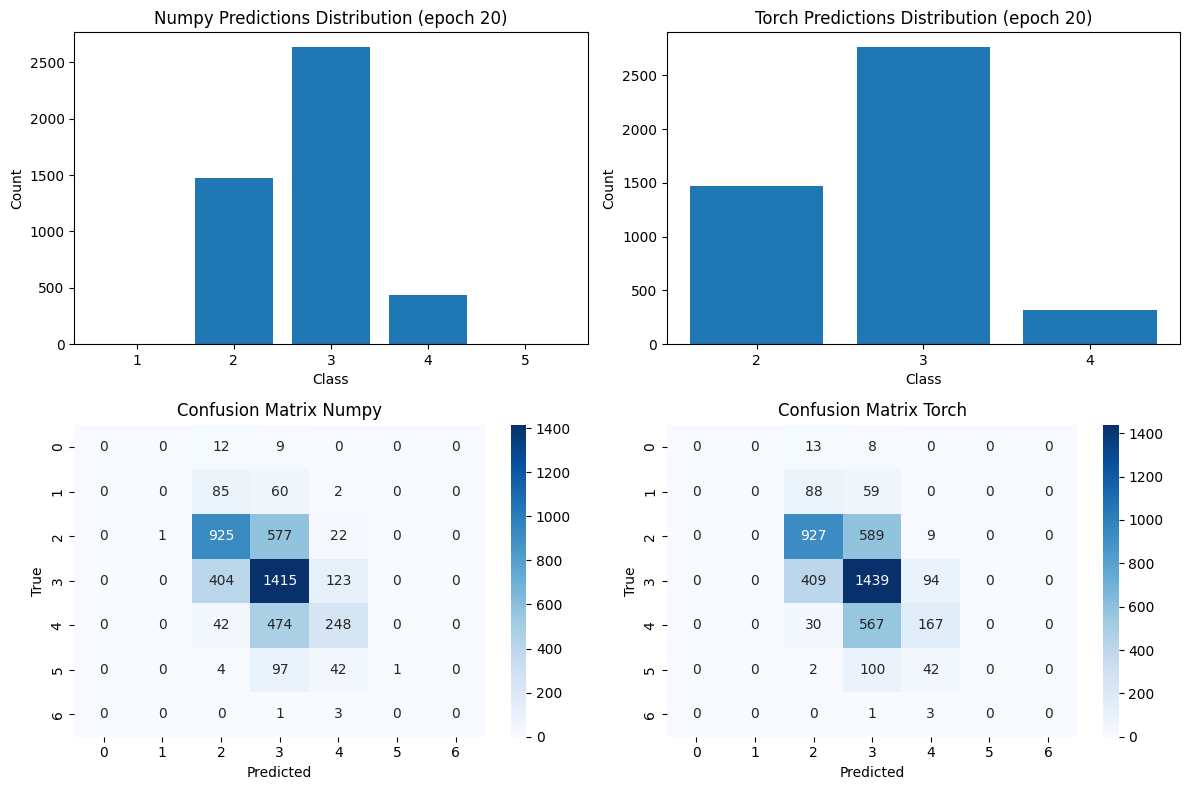

In [36]:
for epoch in range(epoches):
    torch_model.train()
    torch_all_preds = []
    all_preds = []
    all_target = []
    for data, target in loader:
        torch_optimizer.zero_grad()
        torch_output = torch_model(data)
        torch_loss = torch_criterion(torch_output, target)

        torch_loss.backward()
        torch_optimizer.step()

        with torch.no_grad() :
            torch_preds = torch_output.argmax(dim=1)
            torch_all_preds.append(torch_preds)

        data_np = data.numpy()
        target_np = target.numpy()

        optimizer.zero_grad()
        output = model.model.forward(data_np)
        loss = criterion.forward(output, target_np)

        preds = model.predict(data_np)
        all_preds.append(preds)

        grad = criterion.backward()
        model.model.backward(grad)
        optimizer.step()

        all_target.append(target)

    torch_all_preds = torch.cat(torch_all_preds).numpy()
    all_preds = np.concat(all_preds)
    all_target = np.concat(all_target)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))


    unique, counts = np.unique(all_preds, return_counts=True)
    axes[0][0].bar(unique, counts, tick_label=unique)
    axes[0][0].set_title(f"Numpy Predictions Distribution (epoch {epoch+1})")
    axes[0][0].set_xlabel("Class")
    axes[0][0].set_ylabel("Count")

    cm = confusion_matrix(all_target, all_preds, labels=np.arange(num_classes))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1][0])
    axes[1][0].set_xlabel("Predicted")
    axes[1][0].set_ylabel("True")
    axes[1][0].set_title("Confusion Matrix Numpy")

    unique, counts = np.unique(torch_all_preds, return_counts=True)
    axes[0][1].bar(unique, counts, tick_label=unique)
    axes[0][1].set_title(f"Torch Predictions Distribution (epoch {epoch+1})")
    axes[0][1].set_xlabel("Class")
    axes[0][1].set_ylabel("Count")

    cm = confusion_matrix(all_target, torch_all_preds, labels=np.arange(num_classes))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1][1])
    axes[1][1].set_xlabel("Predicted")
    axes[1][1].set_ylabel("True")
    axes[1][1].set_title("Confusion Matrix Torch")


    plt.tight_layout()
    plt.show()